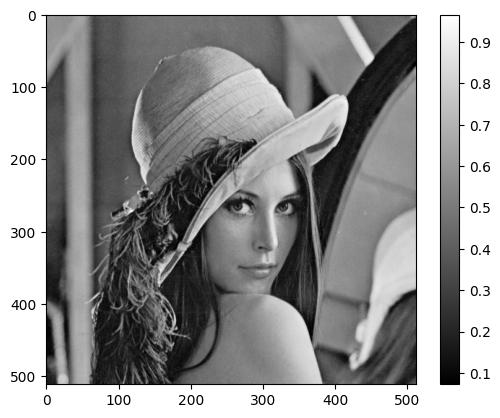

(<Figure size 640x480 with 2 Axes>,
 None)

In [10]:
#### MODELUL MARGINAL ####

import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io

img = io.imread('../lena.png')
Y = color.rgb2gray(img) # intoarce floats in intervalul [0, 1]

# este imagine scalara => obligatoriu colormap
# vreau sa vad luminanta => obligatoriu colormap gri
plt.figure(), plt.imshow(Y, cmap='gray'), plt.colorbar(), plt.show()

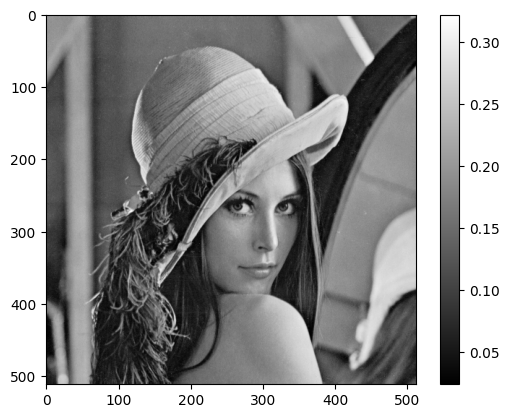

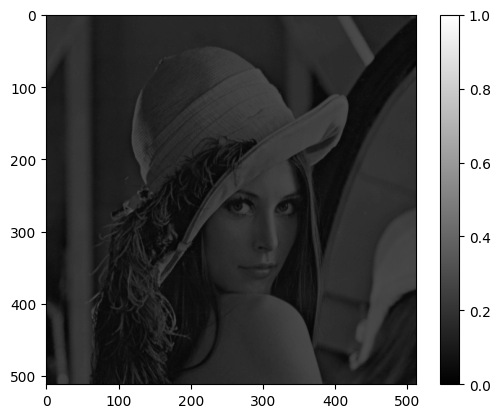

(<Figure size 640x480 with 2 Axes>,
 None)

In [11]:
# vreau sa trec Y printr-o functie de putere
# iau valorile si le ridic la o putere

yout = Y / 3.0

# ma astept ca yout sa fie mai intunecat

plt.figure(), plt.imshow(yout, cmap='gray'), plt.colorbar(), plt.show()
# NU da eroare pentru ca valorile s-au autoscalat

# imaginea e mai intunecata (asa trebuie, corect)
plt.figure(), plt.imshow(yout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


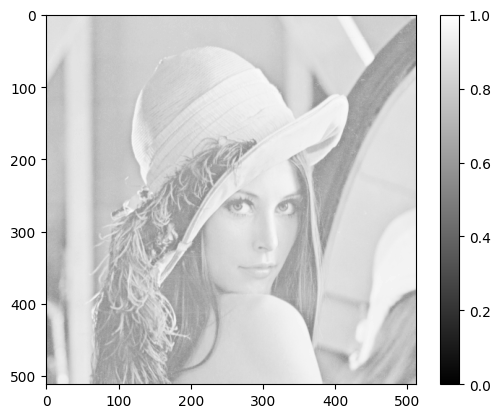

(<Figure size 640x480 with 2 Axes>,
 None)

In [12]:
yout = (Y) ** (0.25)

# imaginea este mai luminoasa (asa trebuie, corect)
plt.figure(), plt.imshow(yout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


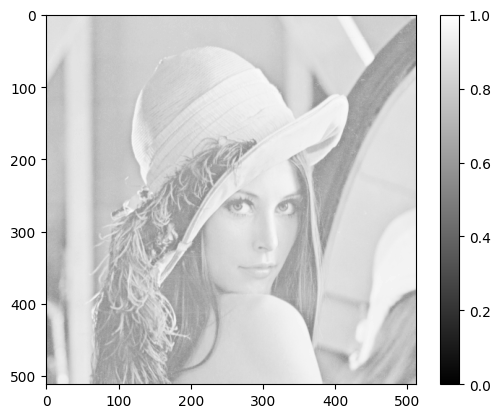

(<Figure size 640x480 with 2 Axes>,
 None)

In [13]:
# acelasi lucru cu ce am facut mai devreme
# nu toate cazurile se rezolva cu prima metoda

[L, C] = np.shape(Y) # nr de linii si de coloane din imagine
yout2 = np.zeros((L, C))

for l in range(0, L):
    for c in range (0, C):
        yout2[l, c] = (Y[l, c]) ** 0.25
        
plt.figure(), plt.imshow(yout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


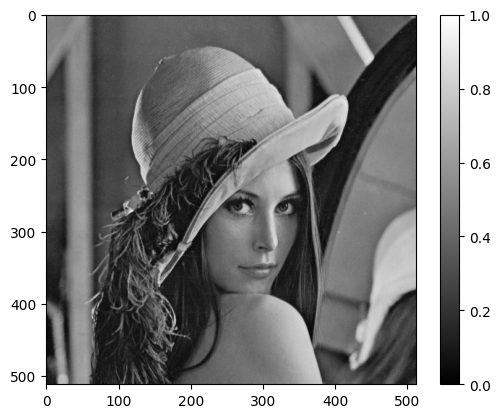

(<Figure size 640x480 with 2 Axes>,
 None)

In [30]:
# def T(grayin):
#     return grayin ** 0.25

def T(grayin, r):
    return grayin ** r

# cu functie 
for l in range(0, L):
    for c in range (0, C):
        yout2[l, c] = T(Y[l, c], 0.25)

# SAU cu dictionar - pe baza de corespondenta a tabelului ??

# construim dictionarul
LUT = np.zeros((256))
for i in range(0, 256):
    # LUT[i] = T(i)     daca am modificat mai jos si am inmultit cu 255 trebuie sa impartim la 255 aici
    LUT[i] = T(i/255.0, 1.25) # pentru r < 1 => poza luminoasa, pentru r > 1 => poza intunecata

for l in range(0, L):
    for c in range (0, C):
        # yout2[l, c] = LUT[Y[l, c]]   asta nu o sa mearga
        yout2[l, c] = LUT[np.uint8(255 * Y[l, c])]
        
plt.figure(), plt.imshow(yout2, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()
        

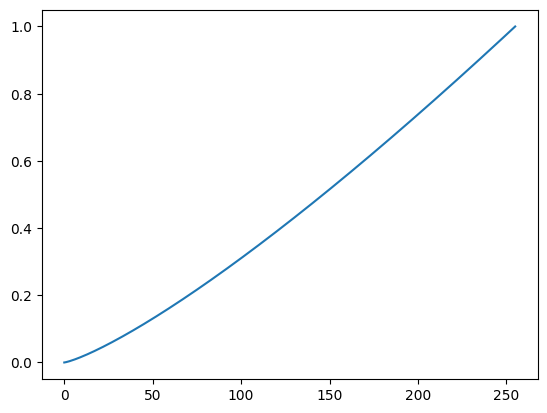

(<Figure size 640x480 with 1 Axes>,
 None)

In [31]:
plt.figure(), plt.plot(LUT), plt.show()

In [40]:
def T(grayin, r):
    return grayin ** r

def prelucrare_scalara(Y):  # reflecta schimbarile in imagine
    LUT = np.zeros((256))
    for i in range(0, 256):
        LUT[i] = T(i / 255.0, 1.25)

    [L, C] = np.shape(Y)
    yout2 = np.zeros((L, C))
    for l in range(0, L):
        for c in range(0, C):
            yout2[l, c] = LUT[np.uint8(255 * Y[l, c])]
            
    return yout2

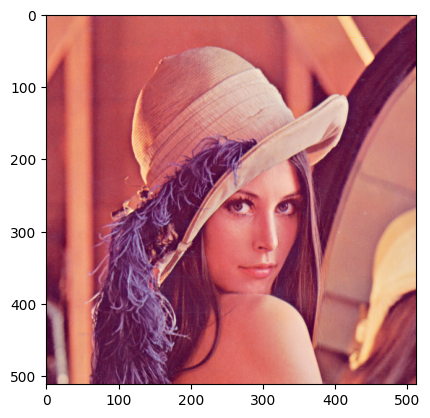

(<Figure size 640x480 with 1 Axes>,
 None)

In [41]:
plt.figure(), plt.imshow(img), plt.show()


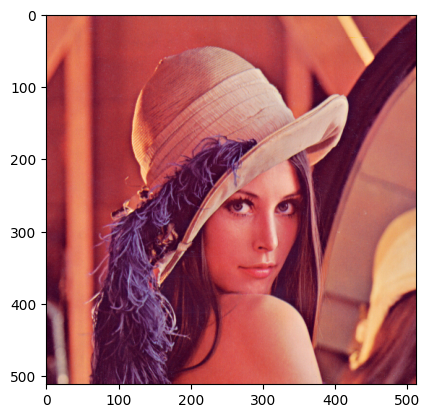

(<Figure size 640x480 with 1 Axes>,
 None)

In [43]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

Rout = prelucrare_scalara(R / 255.0)
Gout = prelucrare_scalara(G / 255.0)
Bout = prelucrare_scalara(B / 255.0)

imgout = np.zeros(np.shape(img))
imgout[:, :, 0] = Rout
imgout[:, :, 1] = Gout
imgout[:, :, 2] = Bout

plt.figure(), plt.imshow(imgout), plt.show()


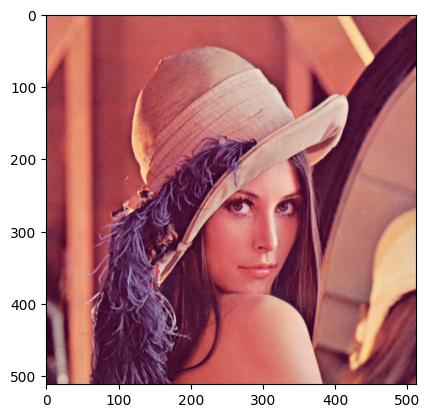

(<Figure size 640x480 with 1 Axes>,
 None)

In [44]:
#### MODELUL DE PRELUCRARE NELINIAR ####
# pt HSV de exemplu

hsv = color.rgb2hsv(img)
V = hsv[:,:,2]
S = hsv[:,:,1]
Vout = prelucrare_scalara(V)
Sout = prelucrare_scalara(S)
hsv[:,:,2] = Vout
hsv[:,:,1] = Sout
rgb_nou = color.hsv2rgb(hsv)

plt.figure(), plt.imshow(rgb_nou), plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


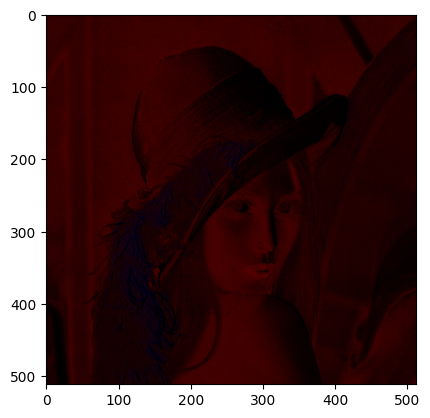

(<Figure size 640x480 with 1 Axes>,
 None)

In [46]:
#### MODELUL DE PRELUCRARE NELINIAR ####
# pt HSV de exemplu

ycbcr = color.rgb2ycbcr(img)
Y = ycbcr[:,:,0]
Yout = prelucrare_scalara(Y)
ycbcr[:,:,0] = Yout
rgb_nou = color.ycbcr2rgb(ycbcr)

plt.figure(), plt.imshow(rgb_nou), plt.show()


In [47]:
print(np.max(rgb_nou))
print(np.min(rgb_nou))

0.35767640352465635
-0.7738151722299366


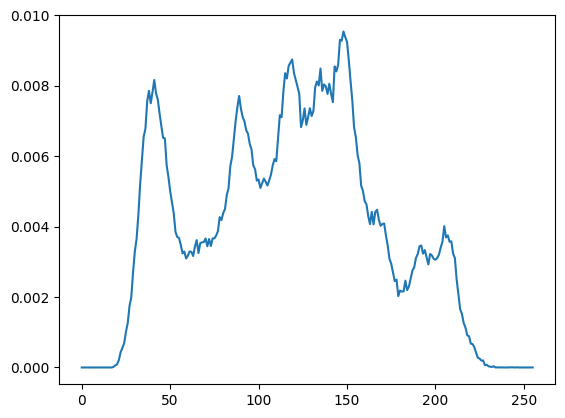

(<Figure size 640x480 with 1 Axes>,
 None)

In [53]:
# egalizare de histograma

img = io.imread('../lena.png')
Yfloat = color.rgb2gray(img)
Y = np.uint8(255 * Yfloat)

[L, C] = np.shape(Y)
contor = np.zeros((256))

for l in range(0, L):
    for c in range(0, C):
        # contor[Y[l, c]] += 1
        contor[np.uint8(255 * Yfloat[l, c])] += 1
        
h = contor / (L * C)   # histograma e contor impartit la nr total de pixeli

plt.figure(), plt.plot(h), plt.show()

(256,)


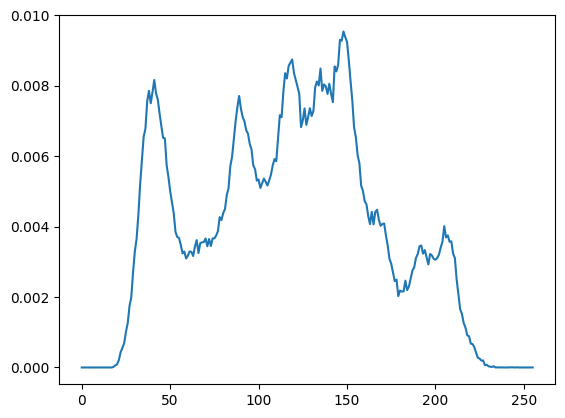

(<Figure size 640x480 with 1 Axes>,
 None)

In [57]:
hh, _ = np.histogram(Y, 256, (0, 256), density = True)

print(np.shape(hh))
plt.figure(), plt.plot(hh), plt.show()


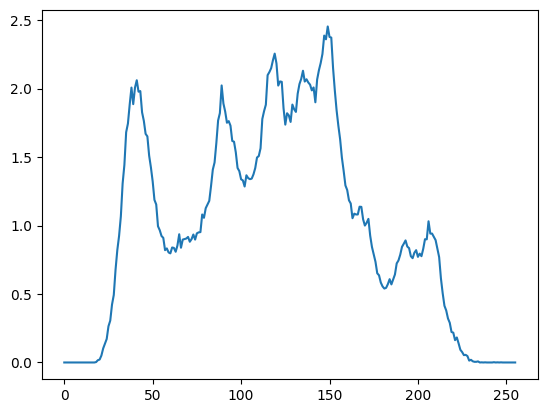

(<Figure size 640x480 with 1 Axes>,
 None)

In [56]:
hhfloat, _ = np.histogram(Yfloat, 256, (0, 1.000000001), density = True)

plt.figure(), plt.plot(hhfloat), plt.show()

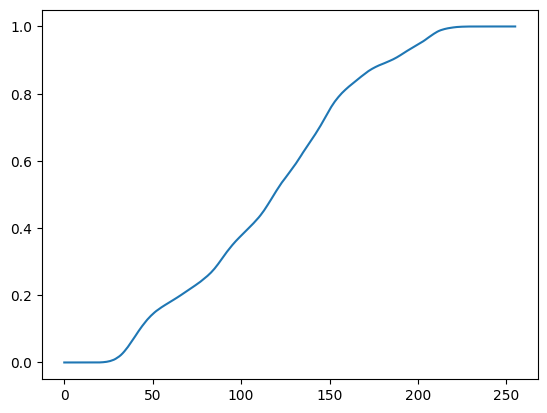

(<Figure size 640x480 with 1 Axes>,
 None)

In [58]:
# histograma cumulativa

# suma cumulativa ?

H = np.cumsum(hh)
plt.figure(), plt.plot(H), plt.show()


In [61]:
# putem sa facem o functie
def egalizare_histograma(Y):
    hhfloat, _ = np.histogram(Yfloat, 256, (0, 1.000000001), density = True)
    H = np.cumsum(hhfloat)
    
    [L, C] = np.shape(Y)
    yout2 = np.zeros((L, C))
    for l in range(0, L):
        for c in range(0, C):
            yout2[l, c] = H[np.uint8(255 * Y[l, c])]
    
    return yout2
    

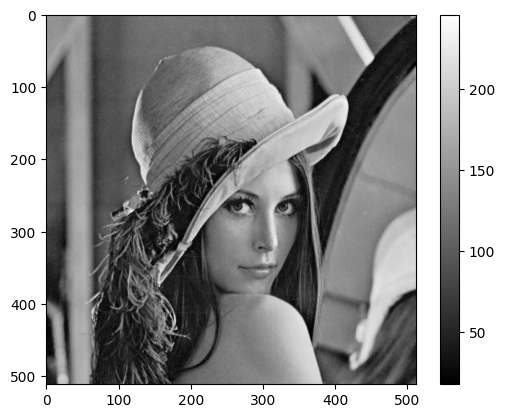

(<Figure size 640x480 with 2 Axes>,
 None)

In [62]:
Ystricat = Yfloat / 2.0

plt.figure(), plt.imshow(Y, cmap='gray'), plt.colorbar(), plt.show()


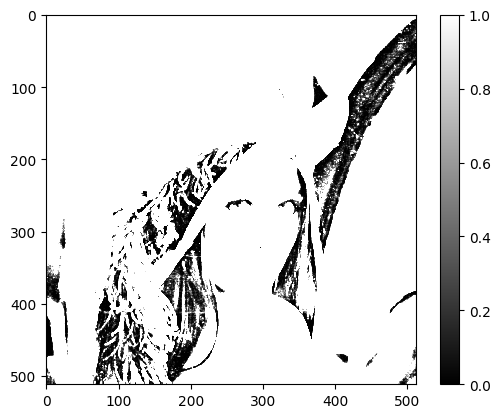

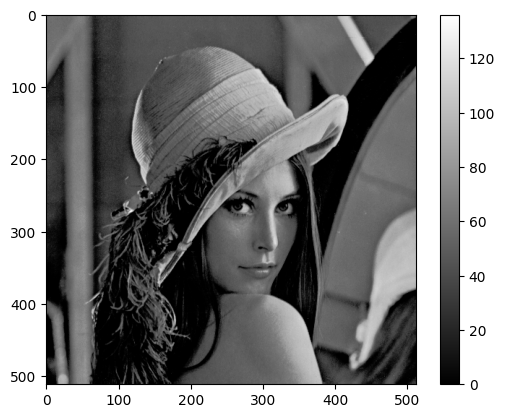

(<Figure size 640x480 with 2 Axes>,
 None)

In [67]:
Yheq =  egalizare_histograma(Ystricat)
plt.figure(), plt.imshow(Yheq, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()
plt.figure(), plt.imshow(Yheq, cmap='gray'), plt.colorbar(), plt.show()


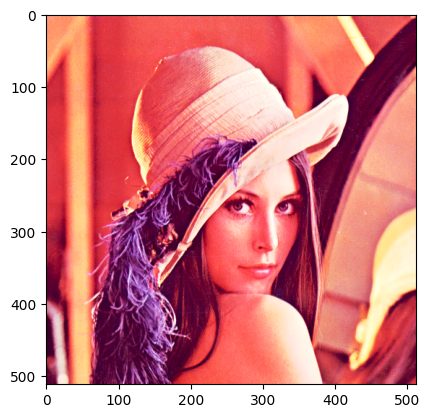

(<Figure size 640x480 with 1 Axes>,
 None)

In [71]:
# model marginal

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

Rout = egalizare_histograma(R / 255.0)
Gout = egalizare_histograma(G / 255.0)
Bout = egalizare_histograma(B / 255.0)

imgout = np.zeros(np.shape(img))
imgout[:, :, 0] = Rout
imgout[:, :, 1] = Gout
imgout[:, :, 2] = Bout

plt.figure(), plt.imshow(np.uint8(imgout)), plt.show()
# plt.figure(), plt.imshow(Rout), plt.show()
# plt.figure(), plt.imshow(Gout), plt.show()
# plt.figure(), plt.imshow(Bout), plt.show()

# sa facem si pt hsv